# Proyecto Final - Curso Data Science I

### Entrega Final
Archivo: ProyectoParteIII_Medran_C

---

##📌 *Abstract*

Este proyecto utiliza el dataset “Spotify Analysis Dataset 2025” proveniente de Kaggle, que contiene información de usuarios de la plataforma de música Spotify. Cada registro corresponde a un usuario e incluye datos demográficos (edad, género, país), características de uso (tiempo de escucha, canciones reproducidas por día, porcentaje de canciones saltadas, minutos de escucha offline, anuncios escuchados) y tipo de suscripción (Free, Premium, Family, Student). La base de datos también incorpora la variable objetivo is_churned, que indica si el usuario canceló o mantuvo su suscripción.




## 🎯*Objetivo del proyecto*
El objetivo de este estudio es desarrollar un modelo predictivo de clasificación que permita identificar la probabilidad de cancelación de suscripciones en usuarios de Spotify, en función de sus características de uso y tipo de cuenta. Se busca comprender qué factores influyen con mayor peso en la decisión de cancelar el servicio, de modo que esta información pueda ser utilizada para estrategias de retención de clientes.

Este trabajo complementa el análisis exploratorio realizado en etapas anteriores, donde se describieron patrones de comportamiento entre usuarios activos y cancelados. En esta instancia, se busca construir un modelo de machine learning que prediga el estado de suscripción del usuario (“activo” o “cancelado”) a partir de las variables más relevantes.

## *Metodología*

Para abordar este objetivo, se aplicará un método de selección de características mediante SelectKBest con el fin de reducir la dimensionalidad del conjunto de datos, eliminando variables redundantes o con baja relevancia predictiva. Posteriormente, se entrenará un modelo de Regresión Logística y un modelo Random Forest, dado que se trata de un problema de clasificación binaria.
El desempeño del modelo se evaluará con métricas de rendimiento como accuracy, precision, recall y F1-score

## ❓Preguntas Exploración Descriptiva
1. ¿Cómo se distribuye el tiempo de escucha diario de los usuarios de Spotify?
2. ¿Existe relación entre el tipo de suscripción y la tasa de cancelación de suscripción?
3. ¿Cómo se relacionan el número de canciones reproducidas por día, el porcentaje de canciones saltadas y la cancelación de suscripciones de los usuarios?

In [ ]:
# Librerías
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Cargar base de datos
path_base = "https://raw.githubusercontent.com/catalinamedran/Entrega1/refs/heads/main/Datasets/spotify_churn_dataset.csv"
df = pd.read_csv(path_base)
df.head()

,user_id,gender,age,country,subscription_type,listening_time,songs_played_per_day,skip_rate,device_type,ads_listened_per_week,offline_listening,is_churned
0,1,Female,54,CA,Free,26,23,0.20,Desktop,31,0,1
1,2,Other,33,DE,Family,141,62,0.34,Web,0,1,0
2,3,Male,38,AU,Premium,199,38,0.04,Mobile,0,1,1
3,4,Female,22,CA,Student,36,2,0.31,Mobile,0,1,0
4,5,Other,29,US,Family,250,57,0.36,Mobile,0,1,1


In [ ]:
# Cantidad de valores faltantes por columna
missing = df.isna().sum().sort_values(ascending=False)
# Mostrar solo las columnas que tienen al menos un valor faltante
missing[missing > 0]


,0


👉 No se observan valores faltantes en las columnas del dataset

##📈*1. Distribución del tiempo de escucha diario de los usuarios de Spotify*


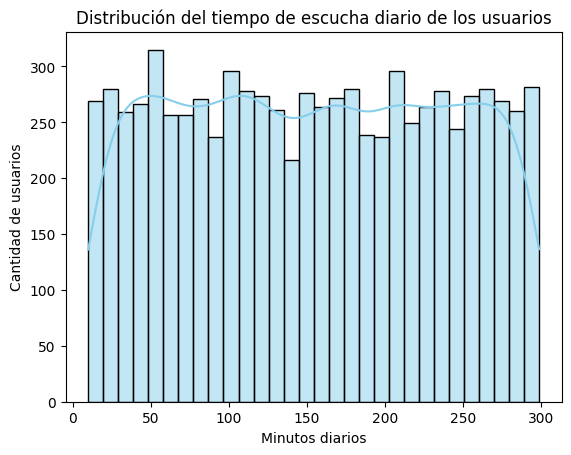

In [ ]:
# Histograma + KDE de listening_time
sns.histplot(df["listening_time"], kde=True, bins=30, color="skyblue")
plt.title("Distribución del tiempo de escucha diario de los usuarios")
plt.xlabel("Minutos diarios")
plt.ylabel("Cantidad de usuarios")
plt.show()

##📈*2. Relación entre el tipo de suscripción y la tasa de cancelación*


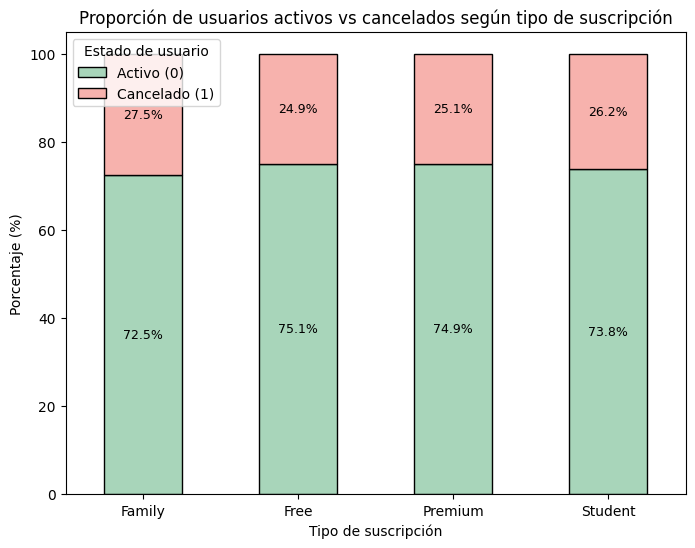

In [ ]:
# Crear tabla de frecuencias cruzadas normalizada (porcentaje)
churn_subs = pd.crosstab(df['subscription_type'], df['is_churned'], normalize='index') * 100
churn_subs.columns = ['Activo (0)', 'Cancelado (1)']

# Colores pasteles
colors = ["#A8D5BA", "#F7B2AD"]  # verde pastel y rojo pastel

# Gráfico de barras apiladas normalizadas
ax = churn_subs.plot(
    kind="bar",
    stacked=True,
    figsize=(8,6),
    color=colors,
    edgecolor="black"
)

# Título y etiquetas
plt.title("Proporción de usuarios activos vs cancelados según tipo de suscripción")
plt.xlabel("Tipo de suscripción")
plt.ylabel("Porcentaje (%)")
plt.legend(title="Estado de usuario")
plt.xticks(rotation=0)

# Agregar porcentajes sobre las barras
for i, row in enumerate(churn_subs.values):
    acumulado = 0
    for j, val in enumerate(row):
        acumulado += val
        plt.text(
            i,                      # posición en x
            acumulado - (val / 2),  # posición en y (centro de cada bloque)
            f"{val:.1f}%",          # texto
            ha="center", va="center", fontsize=9, color="black"
        )

plt.show()

##📈*3. Relación entre la tasa de cancelación según cuartiles de canciones reproducidas por día y cuartiles de tasa de salto de canciones*


/tmp/ipython-input-3025306337.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(


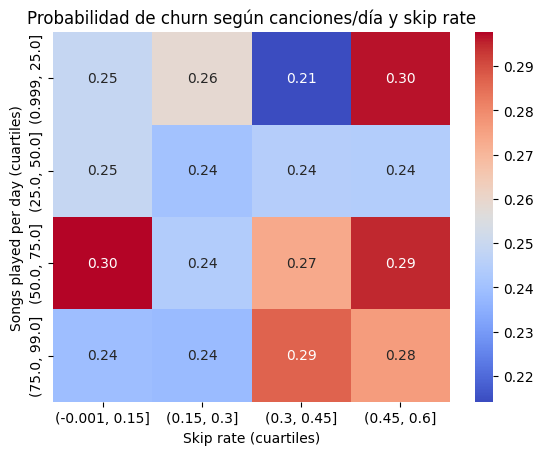

In [ ]:
# Creación de tabla pivot
pivot = df.pivot_table(
    index=pd.qcut(df['songs_played_per_day'], 4),
    columns=pd.qcut(df['skip_rate'], 4),
    values='is_churned',
    aggfunc='mean'
)

# Heatmap
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Probabilidad de churn según canciones/día y skip rate")
plt.xlabel("Skip rate (cuartiles)")
plt.ylabel("Songs played per day (cuartiles)")
plt.show()


##✅*Conclusiones preliminares*


1. En el análisis univariado de tiempo de escucha diario, se observa que los usuarios de Spotify presentan una distribución relativamente uniforme en sus minutos diarios de escucha, con pocos casos extremos. Esto indica que, en general, no hay un grupo dominante de usuarios que escuche significativamente más o menos que el resto.
2. El análisis de la tasa de cancelación según el tipo de suscripción muestra que en todos los planes la mayoría de los usuarios se mantiene activo (más del 70%), aunque existen diferencias leves entre categorías: los planes Free y Premium presentan la menor proporción de cancelación, con aproximadamente un 25% de usuarios dados de baja mientras que los planes Family y Student exhiben tasas de cancelación apenas más altas, cercanas al 27%.
En general, se observa que ningún tipo de suscripción garantiza una permanencia absoluta, pero los usuarios de planes Free y Premium tienden a mostrar una mayor fidelidad relativa en comparación con otros planes.
3. El análisis multivariado evidencia que los usuarios con mayor porcentaje de saltos de canciones presentan también mayores tasas de cancelación, especialmente aquellos que escuchan pocas canciones por día. En contraste, los usuarios con un nivel moderado de reproducción diaria y bajo skip rate muestran los valores más bajos de churn. Incluso entre quienes reproducen muchas canciones, un skip rate elevado se asocia con niveles relativamente altos de cancelación, lo que refleja una tendencia de a mayor skips de canciones, mayor es el churn.


##*Outliers Detection con IQR*

In [ ]:
original_size = df.shape[0]
print(f"Tamaño original del dataset: {original_size}")

Tamaño original del dataset: 8000


In [ ]:
# Columnas numéricas a analizar
numeric_cols = [
    'age',
    'listening_time',
    'songs_played_per_day',
    'skip_rate',
    'ads_listened_per_week',
    'offline_listening'
]
report = []

df_clean = df.copy()  # Copia para limpiar sin perder original

for col in numeric_cols:
    original_size = df_clean.shape[0]

    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Filtrar outliers
    df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]

    iqr_size = df_clean.shape[0]
    iqr_removed = original_size - iqr_size

    report.append({
        'Columna': col,
        'Tamaño original': original_size,
        'Tamaño final': iqr_size,
        'Registros eliminados': iqr_removed,
        'Porcentaje eliminado (%)': round(100 * iqr_removed / original_size, 2)
    })

# Mostrar reporte
report_df = pd.DataFrame(report)
print(report_df)
print(f"\nTamaño final del dataset limpio: {df_clean.shape[0]}")

                 Columna  Tamaño original  Tamaño final  Registros eliminados  \
0                    age             8000          8000                     0   
1         listening_time             8000          8000                     0   
2   songs_played_per_day             8000          8000                     0   
3              skip_rate             8000          8000                     0   
4  ads_listened_per_week             8000          6317                  1683   
5      offline_listening             6317          5982                   335   

   Porcentaje eliminado (%)  
0                      0.00  
1                      0.00  
2                      0.00  
3                      0.00  
4                     21.04  
5                      5.30  

Tamaño final del dataset limpio: 5982


Se analizaron las variables cuantitativas del dataset, ya que son las que pueden presentar outliers. Para cada una de ellas se aplicó el método IQR, identificando y eliminando los valores extremos. De esta forma, se redujo la influencia de registros atípicos que podrían afectar el análisis posterior y los resultados de los modelos.

In [ ]:
# --- Detección y manejo de duplicados ---

# Verificamos la cantidad de filas duplicadas en el dataset completo
duplicados = df.duplicated().sum()
print(f"Cantidad de filas duplicadas: {duplicados}")

# Si existen duplicados, mostramos algunos ejemplos
if duplicados > 0:
    display(df[df.duplicated()].head())

# Eliminamos los duplicados si los hubiera
df = df.drop_duplicates()

# Verificamos nuevamente el total de filas
print(f"Cantidad de filas después de eliminar duplicados: {df.shape[0]}")


Cantidad de filas duplicadas: 0
Cantidad de filas después de eliminar duplicados: 8000


Se realizó la detección de registros duplicados para asegurar la integridad del dataset y evitar sesgos en el análisis y modelado posterior. No se encontraron valores duplicados.

##🧩*Transformación de datos*


###1. Codificación de variables categóricas
Las variables categóricas del dataset son:
* gender
* country
* subscription_type
* device_type

###2. Estandarización de variables numéricas
Las variables numéricas del dataset son:
* age
* listening_time
* songs_played_per_day
* skip_rate
* ads_listened_per_week
* offline_listening

In [ ]:
# Label Encoding para categóricas
from sklearn.preprocessing import LabelEncoder, MinMaxScaler


# Partimos desde el df original (ya limpio de nulos/duplicados/outliers)
df_clean = df.copy()


# 2) Label Encoding para columnas categóricas (cada categoría -> entero)
cat_cols = ['gender', 'country', 'subscription_type', 'device_type']
label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    # Aseguramos que las columnas sean tipo string (por si hay numeros mezclados)
    df_clean[col] = df_clean[col].astype(str)
    df_clean[col] = le.fit_transform(df_clean[col])
    label_encoders[col] = le
    # Mostrar el mapeo (categoría -> entero)
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f"\nMapping for '{col}':")
    print(mapping)

# 3) Seleccionar columnas numéricas para normalizar (excluimos user_id e is_churned)
num_features = ['age', 'listening_time', 'songs_played_per_day',
                'skip_rate', 'ads_listened_per_week', 'offline_listening']

# Verificamos que todas las columnas estén presentes
missing_num = [c for c in num_features if c not in df_clean.columns]
if missing_num:
    raise ValueError(f"Faltan columnas numéricas esperadas: {missing_num}")

# 4) Normalización Min-Max (0-1)
scaler = MinMaxScaler()
df_clean[num_features] = scaler.fit_transform(df_clean[num_features])

# 5) Crear df_encoded listo para modelado (sin modificar user_id e incluyendo target)
# Nota: ya codificamos las categóricas en df_clean, por lo que simplemente renombramos variable
df_encoded = df_clean.copy()

# 6) Reporte final: formas y primeras filas
print("\nDimensiones del dataset procesado:", df_encoded.shape)
display(df_encoded.head())





Mapping for 'gender':
{'Female': np.int64(0), 'Male': np.int64(1), 'Other': np.int64(2)}

Mapping for 'country':
{'AU': np.int64(0), 'CA': np.int64(1), 'DE': np.int64(2), 'FR': np.int64(3), 'IN': np.int64(4), 'PK': np.int64(5), 'UK': np.int64(6), 'US': np.int64(7)}

Mapping for 'subscription_type':
{'Family': np.int64(0), 'Free': np.int64(1), 'Premium': np.int64(2), 'Student': np.int64(3)}

Mapping for 'device_type':
{'Desktop': np.int64(0), 'Mobile': np.int64(1), 'Web': np.int64(2)}

Dimensiones del dataset procesado: (8000, 12)


,user_id,gender,age,country,subscription_type,listening_time,songs_played_per_day,skip_rate,device_type,ads_listened_per_week,offline_listening,is_churned
0,1,0,0.883721,1,1,0.055363,0.224490,0.333333,0,0.632653,0.0,1
1,2,2,0.395349,2,0,0.453287,0.622449,0.566667,2,0.000000,1.0,0
2,3,1,0.511628,0,2,0.653979,0.377551,0.066667,1,0.000000,1.0,1
3,4,0,0.139535,1,3,0.089965,0.010204,0.516667,1,0.000000,1.0,0
4,5,2,0.302326,7,0,0.830450,0.571429,0.600000,1,0.000000,1.0,1


##🧩*Selección de características*
Para reducir la dimensionalidad y seleccionar las características más predictivas para el modelo de churn, se empleó el método de filtro SelectKBest con la prueba estadística ANOVA F-value (f_classif), adecuada para una variable objetivo categórica (churn: 0 o 1).

In [ ]:
# --- Feature Selection con SelectKBest ---
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import train_test_split
import pandas as pd

# Separar X (predictoras) e y (objetivo)
X = df_encoded.drop(columns=['is_churned', 'user_id'])  # user_id no aporta información predictiva
y = df_encoded['is_churned']

# Dividir datos en entrenamiento y testeo
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Aplicar SelectKBest (seleccionamos las 5 mejores features)
selector = SelectKBest(score_func=f_classif, k=5)
X_new = selector.fit_transform(X_train, y_train)

# Identificar las columnas seleccionadas
selected_features = X_train.columns[selector.get_support()]

# Mostrar resultados ordenados por score
feature_scores = pd.DataFrame({
    'Feature': X_train.columns,
    'Score': selector.scores_
}).sort_values(by='Score', ascending=False)

print("✅ Variables seleccionadas por SelectKBest:\n")
print(selected_features)
print("\n📊 Ranking de importancia de variables:")
display(feature_scores.head(5))


✅ Variables seleccionadas por SelectKBest:

Index(['subscription_type', 'listening_time', 'songs_played_per_day',
       'skip_rate', 'offline_listening'],
      dtype='object')

📊 Ranking de importancia de variables:


,Feature,Score
5,songs_played_per_day,3.542976
6,skip_rate,1.436670
4,listening_time,1.175621
9,offline_listening,0.721186
3,subscription_type,0.669326


Se decidió seleccionar las k=5 características con mayor puntuación. Esta elección representa un balance entre simplificar el modelo y retener la información predictiva más relevante identificada por el método estadístico.

##*RECOMENDACIÓN CONCLUSIVA - FEATURES PARA MODELO DE ML*

Los resultados de SelectKBest validan y cuantifican las observaciones realizadas durante el Análisis Exploratorio de Datos (EDA) inicial:

* **Pregunta 3 (Comportamiento de Uso)**: Las variables **songs_played_per_day** (Score: 3.54) y **skip_rate** (Score: 1.44) obtuvieron los puntajes más altos, confirmando que el volumen y la calidad de la interacción (saltar canciones es señal de insatisfacción) son los predictores más fuertes del abandono. Esto se alinea con el heatmap del EDA, que mostró una alta probabilidad de churn para usuarios con bajo volumen y alto skip rate. Recomendación: INCLUIR songs_played_per_day COMO FEATURE PRINCIPAL y **skip_rate** COMO FEATURE ESENCIAL.

* **Pregunta 1 (Tiempo de Escucha)**: La variable listening_time (Score: 1.18) se clasificó como la tercera más importante. Si bien su distribución era relativamente uniforme, su impacto predictivo es moderado, indicando que la duración total de escucha es relevante, pero menos decisiva que el número de canciones o los saltos. Recomendación: INCLUIR COMO FEATURE SECUNDARIO

* **Pregunta 2 (Tipo de Suscripción)**: La variable subscription_type (Score: 0.67) fue la quinta seleccionada, con el puntaje más bajo entre las elegidas. Esto refuerza la conclusión del EDA de que, si bien existen leves diferencias en la tasa de churn entre planes, el tipo de suscripción tiene una influencia predictiva menor en comparación con las métricas de comportamiento directo del usuario.Recomendación: INCLUIR SI SE BUSCA MÁXIMA PRECISIÓN

* **Feature Adicional**: offline_listening (Score: 0.72) se posicionó como la cuarta variable, sugiriendo una influencia predictiva baja pero superior al tipo de suscripción.Recomendación: INCLUIR SI SE BUSCA MÁXIMA PRECISIÓN

* **Features a descartar**: age, gender, country, listening_time, device_type, ads_listened_per_week ya que obtuvieron los puntajes significativamente más bajos. Recomendación: EXCLUIR DEL MODELO

##*Modelo de Machine Learning*

In [ ]:

# Usamos las 5 mejores variables del SelectKBest
selected_features = ['songs_played_per_day', 'skip_rate', 'listening_time', 'offline_listening', 'subscription_type']

X = df_encoded[selected_features]
y = df_encoded["is_churned"]

# --- Dividir en train/test (reutilizando la división anterior) ---
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


# --- Modelo de regresión logística ---
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Usamos class_weight='balanced' para mitigar el desbalance (si existe) entre churn=0 y churn=1
model = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
model.fit(X_train, y_train)

# --- Predicciones ---
y_pred = model.predict(X_test)

# --- Métricas ---
print("=== Métricas del modelo (Regresión Logística - K=5 Features) ===")
print(f"Exactitud (Accuracy): {accuracy_score(y_test, y_pred):.4f}")
print(f"Precisión (Precision): {precision_score(y_test, y_pred):.4f}")
print(f"Sensibilidad (Recall): {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")

# --- Matriz de confusión ---
print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred))

# --- Reporte de clasificación ---
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))

=== Métricas del modelo (Regresión Logística - K=5 Features) ===
Exactitud (Accuracy): 0.4906
Precisión (Precision): 0.2576
Sensibilidad (Recall): 0.5145
F1 Score: 0.3433

Matriz de confusión:
[[572 614]
 [201 213]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.74      0.48      0.58      1186
           1       0.26      0.51      0.34       414

    accuracy                           0.49      1600
   macro avg       0.50      0.50      0.46      1600
weighted avg       0.62      0.49      0.52      1600



In [ ]:
# --- Nuevo Modelo: Random Forest (Mejor para problemas no lineales) ---
from sklearn.ensemble import RandomForestClassifier

# Usamos las mismas features seleccionadas por SelectKBest para mantener el K=5
selected_features = ['songs_played_per_day', 'skip_rate', 'listening_time', 'offline_listening', 'subscription_type']
X = df_encoded[selected_features]
y = df_encoded["is_churned"]

# Re-dividir los datos (por seguridad)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


rf_model = RandomForestClassifier(class_weight='balanced', random_state=42, n_estimators=100, max_depth=8)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

# --- Nuevas Métricas ---
print("\n=== Métricas del modelo (Random Forest - K=5 Features) ===")
print(f"Exactitud (Accuracy): {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precisión (Precision) Clase 1: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Sensibilidad (Recall) Clase 1: {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1 Score Clase 1: {f1_score(y_test, y_pred_rf):.4f}")
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_rf))

# Extraer y mostrar la Importancia de Features del RF (Embedded Method)
feature_importances = pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print("\nImportancia de Features según Random Forest:")
print(feature_importances)


=== Métricas del modelo (Random Forest - K=5 Features) ===
Exactitud (Accuracy): 0.6038
Precisión (Precision) Clase 1: 0.2737
Sensibilidad (Recall) Clase 1: 0.3213
F1 Score Clase 1: 0.2956

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.75      0.70      0.72      1186
           1       0.27      0.32      0.30       414

    accuracy                           0.60      1600
   macro avg       0.51      0.51      0.51      1600
weighted avg       0.63      0.60      0.61      1600


Importancia de Features según Random Forest:
listening_time          0.333865
songs_played_per_day    0.308830
skip_rate               0.275793
subscription_type       0.060840
offline_listening       0.020672
dtype: float64


##Resultados
####**Regresión Logística**
El modelo de Regresión Logística, entrenado con las 5 features seleccionadas, obtuvo las siguientes métricas clave en el conjunto de prueba:

* Accuracy (Exactitud): 0.4906 (49.1%)
* Recall (Sensibilidad) para Churn=1: 0.5145 (51.5%)
* Precision (Precisión) para Churn=1: 0.2576 (25.8%)
* F1 Score para Churn=1: 0.3433

Estas métricas indican que el rendimiento del modelo es insuficiente. Una Accuracy por debajo del 50% indica que es peor que una predicción aleatoria. Más importante aún, el Recall del 51.5% significa que el modelo no logra identificar a casi la mitad de los usuarios que realmente abandonarán (altos Falsos Negativos), lo cual es crítico para una estrategia de retención. Además, la baja Precision (25.8%) implica que la mayoría de las alertas de churn generadas por el modelo serían incorrectas (altos Falsos Positivos), llevando a acciones de retención ineficientes.

Motivo del bajo rendimiento: La relación entre las características de uso de Spotify y la decisión de abandono es probablemente no lineal y presenta interacciones complejas (ej., el efecto combinado de skip_rate y songs_played_per_day visto en el EDA). La Regresión Logística, al ser un modelo lineal, no puede capturar adecuadamente estas dinámicas.

####**Modelo No Lineal: Random Forest**

Se entrenó un modelo Random Forest Classifier utilizando las mismas 5 características seleccionadas por SelectKBest. Se mantuvo class_weight='balanced' para intentar compensar el desbalance de clases.

Las métricas obtenidas con el modelo Random Forest en el conjunto de prueba son:

* Accuracy (Exactitud): 0.6038 (60.4%)
* Recall (Sensibilidad) para Churn=1: 0.3213 (32.1%)
* Precision (Precisión) para Churn=1: 0.2737 (27.4%)
* F1 Score para Churn=1: 0.2956 (29.6%)

El Random Forest mejora la Accuracy general respecto a la Regresión Logística (60.4% vs 49.1%), demostrando ser un algoritmo más adecuado para este problema. Sin embargo, el Recall disminuye a 32.1%, lo que significa que el modelo ahora falla en identificar a casi el 68% de los usuarios que abandonarán. La Precision se mantiene baja (27.4%), indicando que las pocas alertas de churn que genera siguen siendo mayormente incorrectas.


##*Conclusiones*

* Feature Selection Confirmada: Tanto el método de filtro (SelectKBest) como el método embedded (Random Forest Feature Importance) coinciden en que las variables clave para predecir el churn son listening_time, songs_played_per_day y skip_rate. Estas tres características explican más del 90% de la importancia predictiva en el modelo Random Forest.

* El modelo Random Forest alcanzó una exactitud (Accuracy) general del 60.4%. Considerando el objetivo del proyecto de desarrollar un modelo predictivo inicial, este nivel de accuracy se considera satisfactorio como punto de partida, indicando que el modelo tiene una capacidad moderada para distinguir entre usuarios que abandonarán y los que permanecerán activos. Aunque la accuracy general es aceptable, el rendimiento en la identificación específica de los usuarios que abandonan (clase 1) es limitado, con un Recall del 32.1% y una Precision del 27.4%. Esto sugiere que, si bien el modelo tiene cierto poder predictivo, aún presenta desafíos para capturar completamente a la población en riesgo de churn.

* Impacto Estratégico: Para reducir el churn, Spotify debería centrar sus esfuerzos en monitorear y mejorar la experiencia de escucha activa. Indicadores como un aumento en skip_rate o una disminución en listening_time son señales de alerta mucho más fuertes que el tipo de plan del usuario. Las estrategias de retención deberían ser proactivas y basarse en estos patrones de uso.

